In [1]:
import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import time



In [2]:
Nx, Ny = 15, 15
Nwalkers = 2000

###  A function that decides if the walker reaches the boundary:

In [3]:
def is_boundary_square(i,j,Nx,Ny):
  return i==0 or i==Nx-1 or j==0 or j==Ny-1

### A function that assigns the temperature at the borders (100,0,0,0):

In [4]:
def boundary_value_square(i,j,Nx,Ny):
  if j==Ny-1:
    return 100
  else:
    return 0

### A function that moves the walker randomly (up, down, left, or right) until it reaches the border:

In [5]:
def random_walk(i,j,is_boundary_func,boundary_value_func,Nx,Ny):
  while not is_boundary_func(i,j,Nx,Ny):
    direction = random.randint(0,3)

    if direction == 0:
      j += 1
    elif direction == 1:
      j -= 1
    elif direction == 2:
      i -= 1
    else:
      i += 1

  return boundary_value_func(i,j,Nx,Ny)


### Define the function Temperatureofpoint:
We makes N ran
dom walks from that point and averages the obtained va
lues. Then temperature at any point as the average of all
Random Walks values at each point.

In [6]:
def temperature_of_point(i,j,Nwalkers,is_boundary_func,boundary_value_func,Nx,Ny):
  sum = 0
  for _ in range(Nwalkers):
    temp = random_walk(i,j,is_boundary_func,boundary_value_func,Nx,Ny)
    sum += temp
  temperature = sum / Nwalkers
  return temperature


### Define the matrix of temperature and a heat map:

In [7]:
def heatmap_square(Nx,Ny):
  T = np.zeros((Nx,Ny))
  for i in range(Nx):
    for j in range(Ny):
      if is_boundary_square(i,j,Nx,Ny):
        T[i,j] = boundary_value_square(i,j,Nx,Ny)
      else:
        T[i,j] = temperature_of_point(i,j,Nwalkers,is_boundary_square,boundary_value_square,Nx,Ny)
  return T


def plot_field(T, title):
    plt.figure(figsize=(6,5))
    sns.heatmap(
        T.T,
        cmap="hot",
        cbar=True,
        square=True,
        xticklabels=True,
        yticklabels=True

    )
    plt.title(title)
    plt.xlabel("i")
    plt.ylabel("j")
    plt.gca().invert_yaxis()




### Draw the graph of the temparture distribution using random walk:

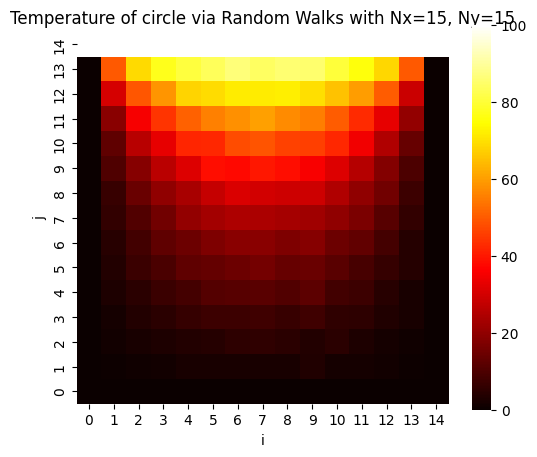

In [8]:
T = heatmap_square(Nx,Ny)
plot_field(T,f"Temperature of circle via Random Walks with Nx={Nx}, Ny={Ny}")
plt.show()

### The convergence analysis:

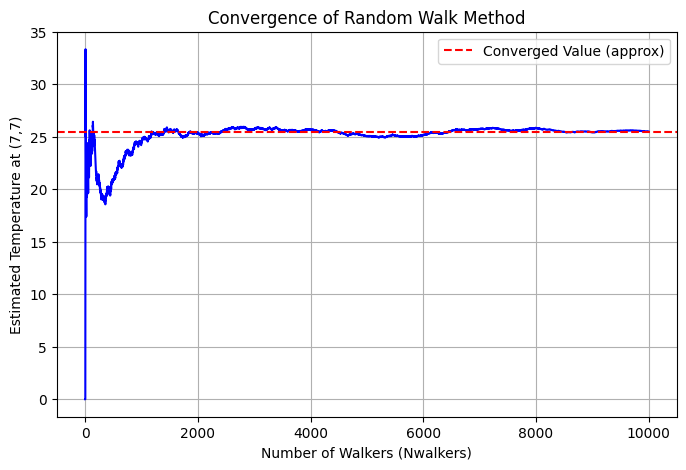

In [9]:
point_i,point_j = 7, 7
walkers_num = 10000
temperatures = np.zeros(walkers_num)

for i in range(walkers_num):
    temperatures[i] = random_walk(point_i, point_j, is_boundary_square, boundary_value_square, Nx, Ny)
temperature = np.cumsum(temperatures) / np.arange(1,walkers_num+1)

plt.figure(figsize=(8, 5))
plt.plot(temperature, color='b')
plt.axhline(y=temperature[-1], color='r', linestyle='--', label='Converged Value (approx)')
plt.xlabel("Number of Walkers (Nwalkers)")
plt.ylabel("Estimated Temperature at (7,7)")
plt.title("Convergence of Random Walk Method")
plt.legend()
plt.grid(True)
plt.show()



Running Nx = Ny = 15
Running Nx = Ny = 21
Running Nx = Ny = 27
Running Nx = Ny = 33


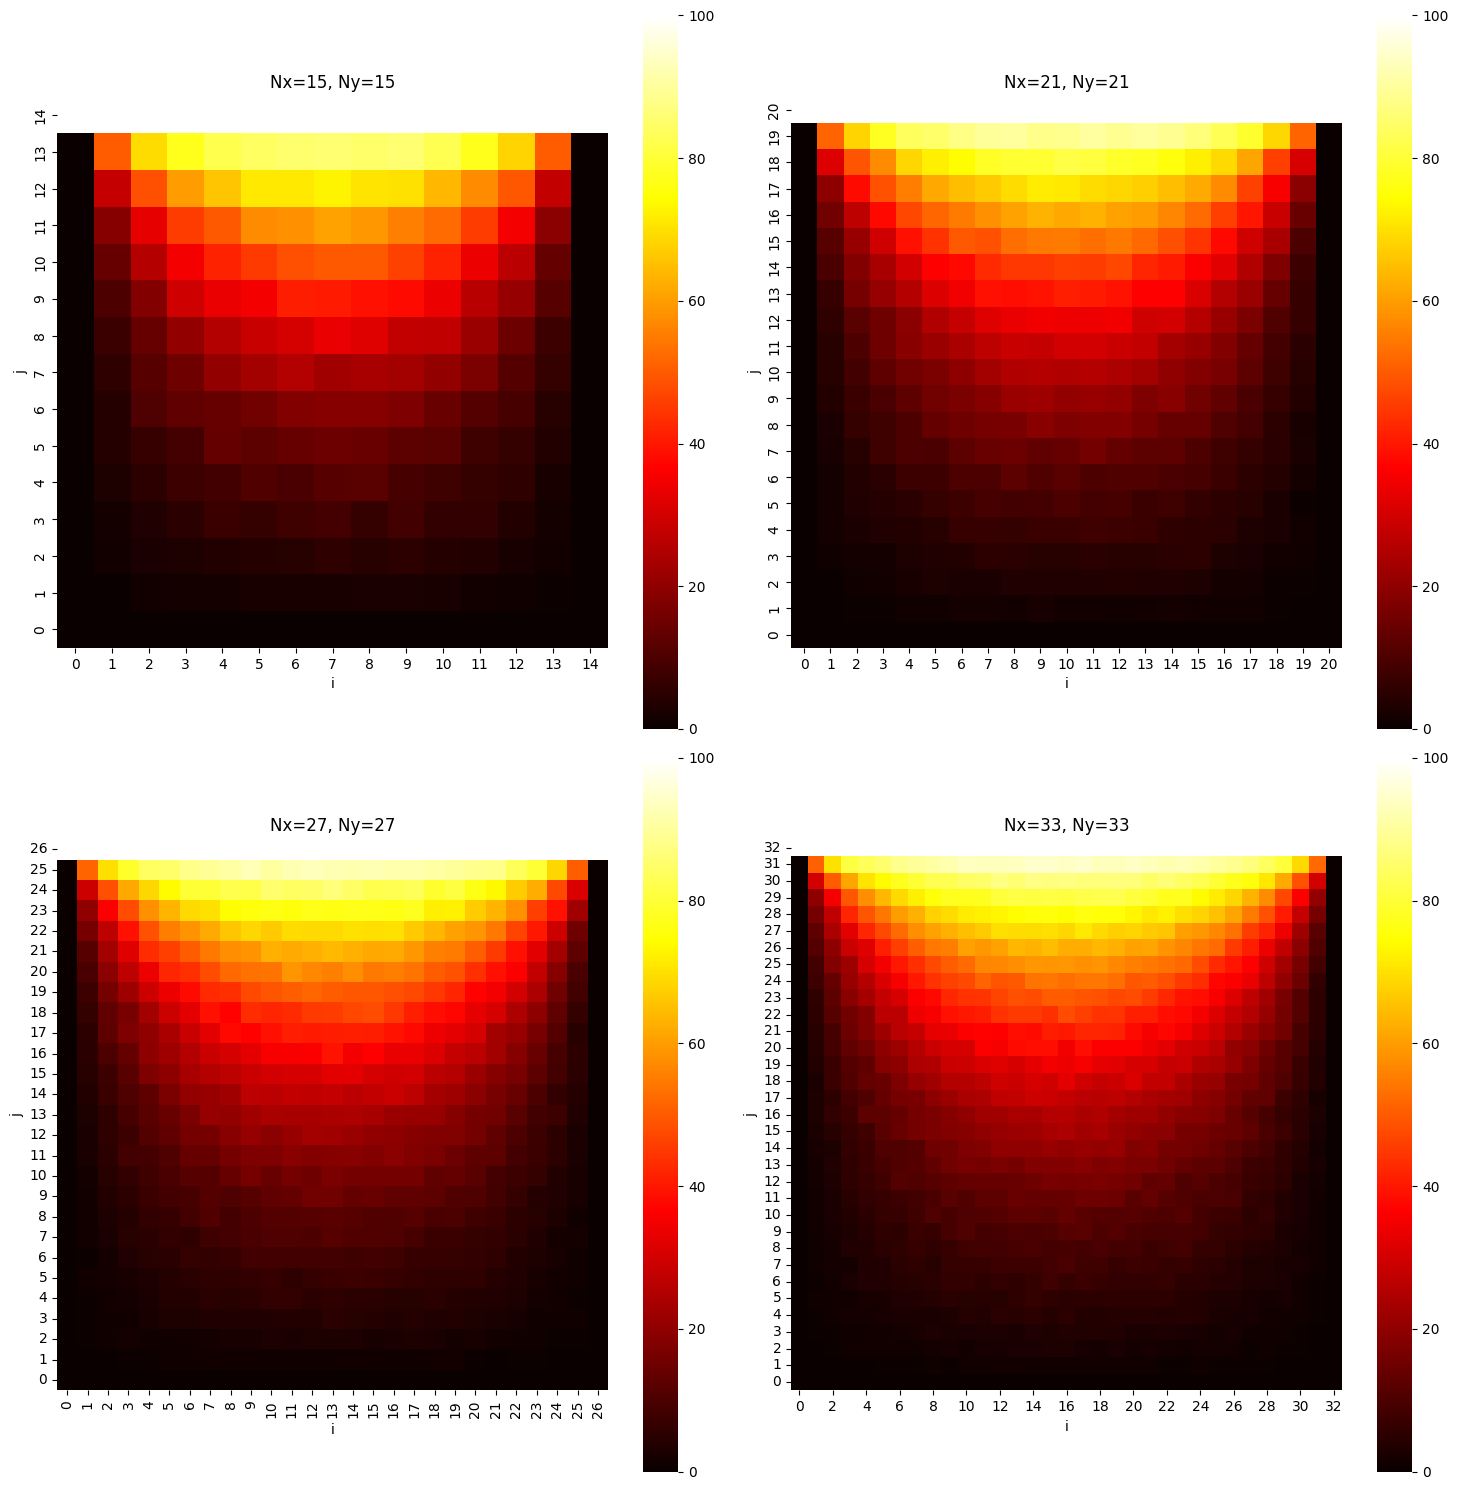

In [10]:
Nx_Ny_list = [15,21,27,33]

fig, axes = plt.subplots(2, 2, figsize=(15, 15))

idx = 0
for i in range(2):
    for j in range(2):
        n = Nx_Ny_list[idx]
        Nx, Ny = n, n

        print(f"Running Nx = Ny = {n}")

        T = heatmap_square(n, n)

        sns.heatmap(
            T.T,
            cmap="hot",
            cbar=True,
            square=True,
            ax=axes[i,j]
        )

        axes[i,j].set_title(f"Nx={n}, Ny={n}")
        axes[i,j].set_xlabel("i")
        axes[i,j].set_ylabel("j")
        axes[i,j].invert_yaxis()

        idx += 1

plt.tight_layout()
plt.show()

###  Full Field Reconstruction:

In [11]:
def finite_difference(if_print=True):
  max_iter = 5000
  tol = 1e-4
  U = np.zeros((Nx,Ny))
  for i in range(Nx):
    for j in range(Ny):
      if is_boundary_square(i,j,Nx,Ny):
        U[i,j]=boundary_value_square(i,j,Nx,Ny)

  U_new = U.copy()
  for it in range(max_iter):
    for i in range(Nx-1):
      for j in range(Ny-1):
        if not is_boundary_square(i,j,Nx,Ny):
          U_new[i,j]=0.25 * (U[i+1, j] + U[i-1, j] + U[i, j+1] + U[i, j-1])
    error = np.max(np.abs(U_new - U))
    if error < tol:
      if if_print:
        print(f"Converged in {it} iterations, error={error}")
      break
    U[:] = U_new[:]
  return U



### Draw the graph of the temparture distribution using finite difference:

Converged in 363 iterations, error=9.880202239642699e-05


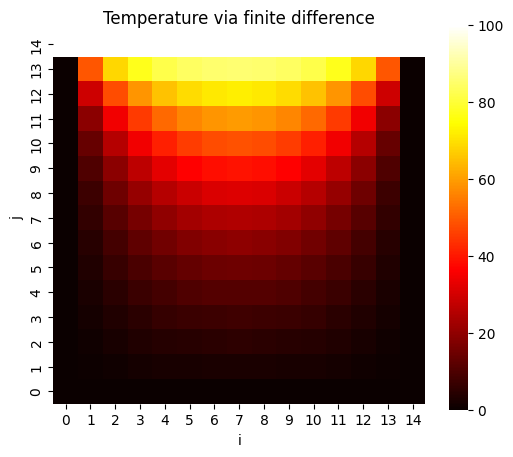

In [12]:
Nx, Ny = 15, 15
Nwalkers = 2000
T = finite_difference()
plot_field(T,"Temperature via finite difference")

### Comparison of computational cost vs finite difference:

=== Computational Cost Comparison ===
Random walk time: 8.5180 s
Finite Difference time: 0.0739 s


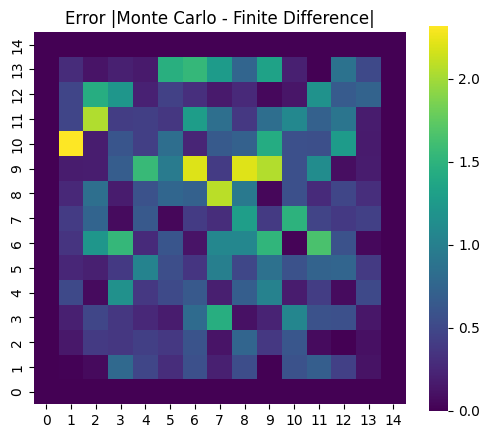

Max error: 2.3199469893200906
Mean error: 0.4574080102617157


In [13]:
start = time.time()
T_mc = np.zeros((Nx,Ny))
for i in range(Nx):
    for j in range(Ny):
        if is_boundary_square(i,j,Nx,Ny):
            T_mc[i,j] = boundary_value_square(i,j,Nx,Ny)
        else:
            T_mc[i,j] = temperature_of_point(i,j,Nwalkers,is_boundary_square,boundary_value_square,Nx,Ny)
t_mc = time.time() - start

# Finite Difference
start = time.time()
T_fd = finite_difference(if_print=False)
t_fd = time.time() - start

print("=== Computational Cost Comparison ===")
print(f"Random walk time: {t_mc:.4f} s")
print(f"Finite Difference time: {t_fd:.4f} s")

error_field = np.abs(T_mc - T_fd)

plt.figure(figsize=(6,5))
sns.heatmap(error_field.T, cmap="viridis", cbar=True, square=True)
plt.title("Error |Monte Carlo - Finite Difference|")
plt.gca().invert_yaxis()
plt.show()

print("Max error:", np.max(error_field))
print("Mean error:", np.mean(error_field))

### Different Geometries:
(i)Circular domain:

In [14]:
r = 7
def is_boundary_circle(i,j,Nx,Ny):
  cx = Nx/2 - 1
  cy = Ny/2 - 1
  r = cx
  return (i-cx)**2 + (j-cy)**2 >= r**2


def boundary_value_circle(i,j,Nx,Ny):
  if j>=7:
    return 100
  else:
    return 0

def heatmap_plot_circle(Nx,Ny):
  T = np.zeros((Nx,Ny))
  for i in range(Nx):
    for j in range(Ny):
      if is_boundary_circle(i,j,Nx,Ny):
        T[i,j] = boundary_value_circle(i,j,Nx,Ny)
      else:
        T[i,j] = temperature_of_point(i,j,Nwalkers,is_boundary_circle,boundary_value_circle,Nx,Ny)

  plt.figure(figsize=(6,5))
  sns.heatmap(
    T.T,
    cmap="hot",
    cbar=True,
    square=True,
    xticklabels=True,
    yticklabels=True
  )

  plt.title(f"Temperature of circle via Random Walks\nNx={Nx}, Ny={Ny}, Nwalks={Nwalkers}, radius={r}")
  plt.xlabel("i")
  plt.ylabel("j")
  plt.gca().invert_yaxis()

  plt.show()



### Draw the graph of the temparture distribution of circle domain:

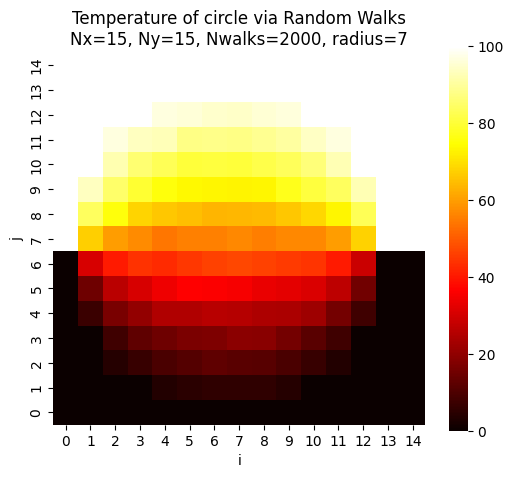

In [15]:
heatmap_plot_circle(Nx,Ny)

(ii)L-shaped domain:

In [16]:
def in_L(i, j, Nx, Ny):
    return (0 <= i < (Nx/2 - 1) and 0 <= j <= Ny) or ((Nx/2 - 1) <= i and 0 <= j < 7)

def is_boundary_L(i, j, Nx, Ny):
    if not in_L(i, j, Nx, Ny):
        return False

    neighbors = [(i+1,j),(i-1,j),(i,j+1),(i,j-1),(i+1,j+1),(i-1,j+1),(i-1,j-1),(i+1,j-1)]

    for ni, nj in neighbors:
        if not in_L(ni, nj, Nx, Ny):
            return True

    return False

def boundary_value_L(i,j, Nx, Ny):
  if i==0 and j <= Ny or j==0:
    return 0
  else:
    return 100


def heatmap_plot_L(Nx, Ny):
  T = np.full((Nx,Ny),100)
  for i in range(Nx):
    for j in range(Ny):
      if not in_L(i, j, Nx, Ny):
        continue
      if is_boundary_L(i,j, Nx, Ny):
        T[i,j] = boundary_value_L(i,j, Nx, Ny)
      else:
        T[i,j] = temperature_of_point(i,j,Nwalkers,is_boundary_L,boundary_value_L, Nx, Ny)

  plt.figure(figsize=(6,5))
  sns.heatmap(
    T.T,
    cmap="hot",
    cbar=True,
    square=True,
    xticklabels=True,
    yticklabels=True
  )

  plt.title(f"Temperature of L shape via Random Walks\nNx={Nx}, Ny={Ny}, Nwalks={Nwalkers}")
  plt.xlabel("i")
  plt.ylabel("j")
  plt.gca().invert_yaxis()
  plt.show()





### Draw the graph of the temparture distribution of L shape domain:

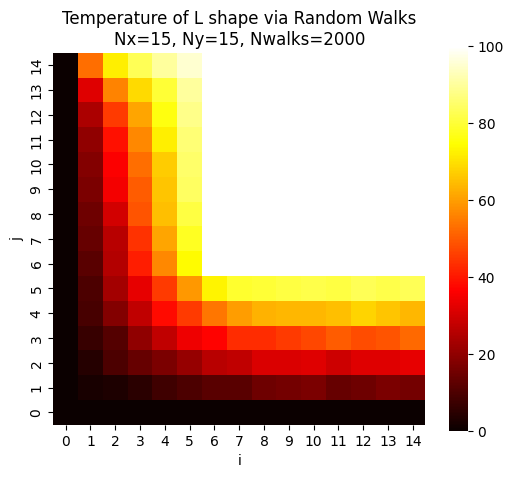

In [17]:
heatmap_plot_L(Nx, Ny)

(iii) Domain with internal obstacles:

In [18]:

def is_boundary_obstacle(i, j, Nx, Ny):
    cx = Nx // 2
    cy = Ny // 2

    return (
        i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1
        or ((i == cx - 1 or i == cx + 1) and (j >= cy - 1 and j <= cy + 1))
        or ((j == cy - 1 or j == cy + 1) and (i >= cx - 1 and i <= cx + 1))
    )


def boundary_value_obstacle(i, j, Nx, Ny):
    cx = Nx // 2
    cy = Ny // 2

    if i == 0 or i == Nx - 1 or j == 0 or j == Ny - 1:
        return 0

    if ((i == cx - 1 or i == cx + 1) and (j >= cy - 1 and j <= cy + 1)) \
       or ((j == cy - 1 or j == cy + 1) and (i >= cx - 1 and i <= cx + 1)):
        return 100


def temperature_of_point(i, j, Nwalkers,
                         is_boundary_obstacle,
                         boundary_value_obstacle,
                         Nx, Ny):

    total = 0

    for _ in range(Nwalkers):
        x, y = i, j

        while not is_boundary_obstacle(x, y, Nx, Ny):
            direction = random.choice([(1,0), (-1,0), (0,1), (0,-1)])
            x += direction[0]
            y += direction[1]

        total += boundary_value_obstacle(x, y, Nx, Ny)

    return total / Nwalkers


def heatmap_plot_obstacle(Nx, Ny):
    T = np.full((Nx, Ny), 100.0)

    cx = Nx // 2
    cy = Ny // 2

    for i in range(Nx):
        for j in range(Ny):

            if i == cx and j == cy:
                T[i, j] = 100

            elif is_boundary_obstacle(i, j, Nx, Ny):
                T[i, j] = boundary_value_obstacle(i, j, Nx, Ny)

            else:
                T[i, j] = temperature_of_point(
                    i, j, Nwalkers,
                    is_boundary_obstacle,
                    boundary_value_obstacle,
                    Nx, Ny
                )
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        T.T,
        cmap="hot",
        cbar=True,
        square=True,
        xticklabels=True,
        yticklabels=True
    )

    plt.title(f"L-shape Temperature (RW)\nNx={Nx}, Ny={Ny}, Nwalks={Nwalkers}")
    plt.xlabel("i")
    plt.ylabel("j")
    plt.gca().invert_yaxis()
    plt.show()


### Draw the graph of the temparture distribution of Domain with internal obstacles:



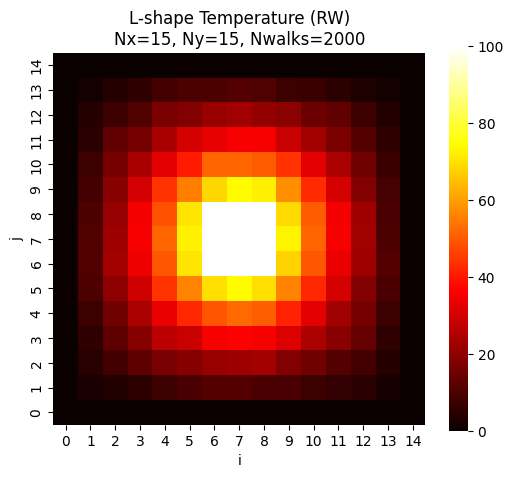

In [19]:
heatmap_plot_obstacle(Nx,Ny)

### Convergence of different domains:

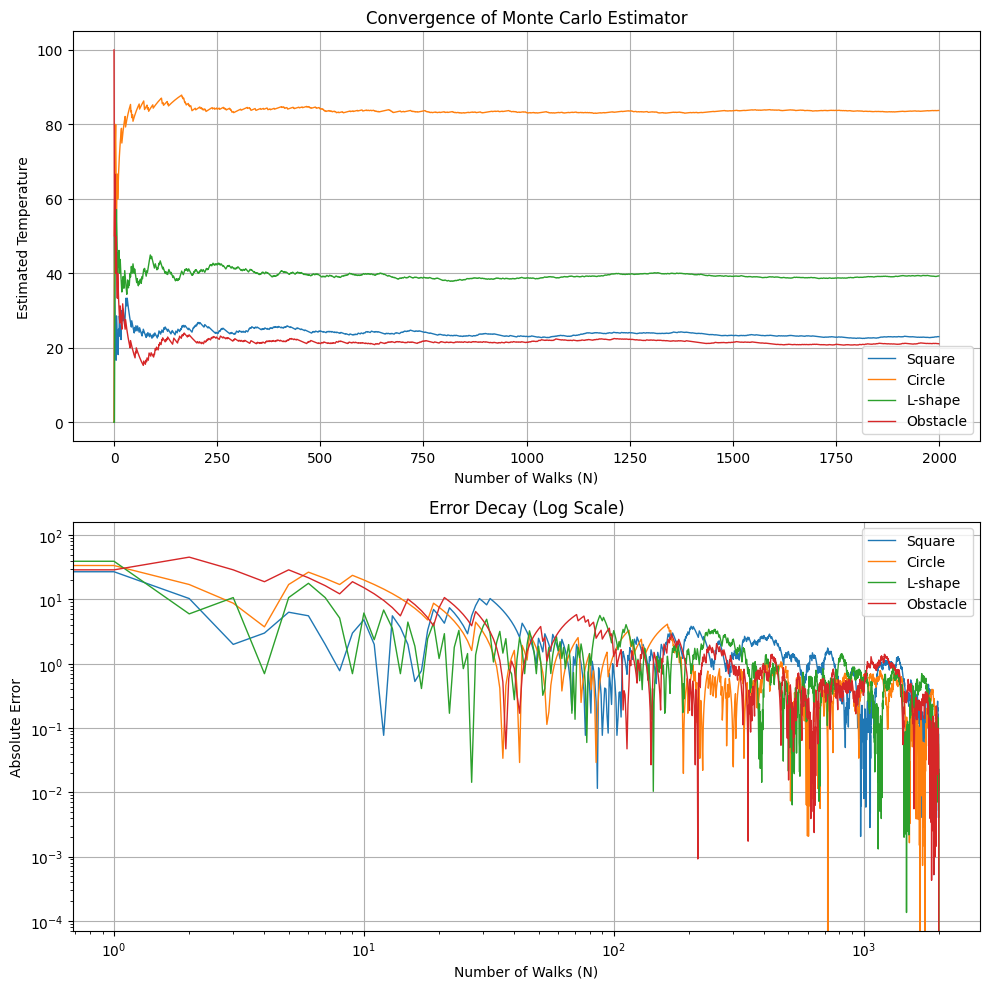

In [20]:
def convergence_curve(point_i, point_j, walkers_num, is_boundary, boundary_value, Nx, Ny):
    temperatures = np.zeros(walkers_num)

    for i in range(walkers_num):
        temperatures[i] = random_walk(point_i, point_j, is_boundary, boundary_value, Nx, Ny)

    return np.cumsum(temperatures) / np.arange(1, walkers_num + 1)

walkers_num = 2000
Nx,Ny = 100,100
pt_sq = (Nx//2, Ny//2)
pt_circle = (Nx//2, Ny//2)
pt_L = (Nx//4, Ny//4)
pt_obs = (Nx//2, Ny//4)


curve_sq = convergence_curve(*pt_sq, walkers_num, is_boundary_square, boundary_value_square,Nx,Ny)

curve_circle = convergence_curve(*pt_circle, walkers_num, is_boundary_circle, boundary_value_circle,Nx,Ny)

curve_L = convergence_curve(*pt_L, walkers_num, is_boundary_L, boundary_value_L,Nx,Ny)

curve_obs = convergence_curve(*pt_obs, walkers_num, is_boundary_obstacle, boundary_value_obstacle,Nx,Ny)

error_sq = np.abs(curve_sq - curve_sq[-1])
error_circle = np.abs(curve_circle - curve_circle[-1])
error_L = np.abs(curve_L - curve_L[-1])
error_obs = np.abs(curve_obs - curve_obs[-1])

fig,axes = plt.subplots(2,1,figsize=(10, 10))


axes[0].plot(curve_sq, label='Square', linewidth=1)
axes[0].plot(curve_circle, label='Circle', linewidth=1)
axes[0].plot(curve_L, label='L-shape', linewidth=1)
axes[0].plot(curve_obs, label='Obstacle', linewidth=1)

axes[0].set_title("Convergence of Monte Carlo Estimator")
axes[0].set_xlabel("Number of Walks (N)")
axes[0].set_ylabel("Estimated Temperature")
axes[0].legend()
axes[0].grid(True)

axes[1].plot(error_sq, label='Square', linewidth=1)
axes[1].plot(error_circle, label='Circle', linewidth=1)
axes[1].plot(error_L, label='L-shape', linewidth=1)
axes[1].plot(error_obs, label='Obstacle', linewidth=1)

axes[1].set_xscale('log')
axes[1].set_yscale('log')
axes[1].set_title("Error Decay (Log Scale)")
axes[1].set_xlabel("Number of Walks (N)")
axes[1].set_ylabel("Absolute Error")
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

###  Electrostatic Problem:

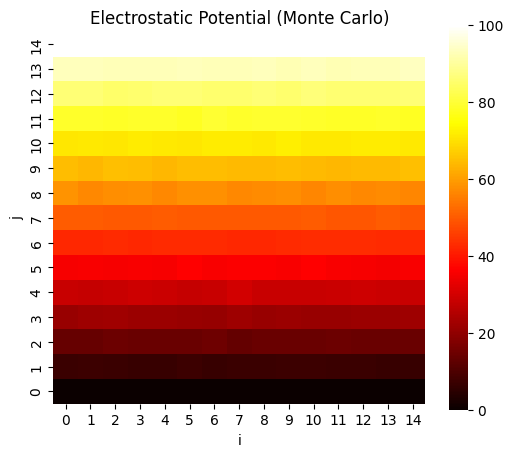

In [21]:
Nx, Ny = 15, 15
Nwalkers = 10000
def is_boundary_electro(i,j, Nx, Ny):
    return j==0 or j==Ny-1

def boundary_value_electro(i,j, Nx, Ny):
    if j == Ny-1:
        return 100
    else:
        return 0

def random_walk_electro(i,j,is_boundary_func,boundary_value_func, Nx, Ny):
  while not is_boundary_func(i,j, Nx, Ny):
    direction = random.choice(['up', 'down', 'left', 'right'])
    if direction == 'up':
      j += 1
    elif direction == 'down':
      j -= 1
    elif direction == 'left':
      i -= 1
    elif direction == 'right':
      i += 1

    if i < 0:
      i = 1
    elif i > Nx-1:
      i = Nx-2

  return boundary_value_func(i,j,Nx, Ny)

def potential_point(i,j,Nwalkers, Nx, Ny):
    total = 0
    for _ in range(Nwalkers):
        total += random_walk_electro(i,j,is_boundary_electro,boundary_value_electro, Nx, Ny)
    return total / Nwalkers
def electrostatic_field_MC(Nx, Ny):
    V = np.zeros((Nx,Ny))

    for i in range(Nx):
        for j in range(Ny):
            if is_boundary_electro(i,j, Nx, Ny):
                V[i,j] = boundary_value_electro(i,j, Nx, Ny)
            else:
                V[i,j] = potential_point(i,j,Nwalkers, Nx, Ny)

    return V

V_mc = electrostatic_field_MC(Nx, Ny)
plot_field(V_mc, "Electrostatic Potential (Monte Carlo)")

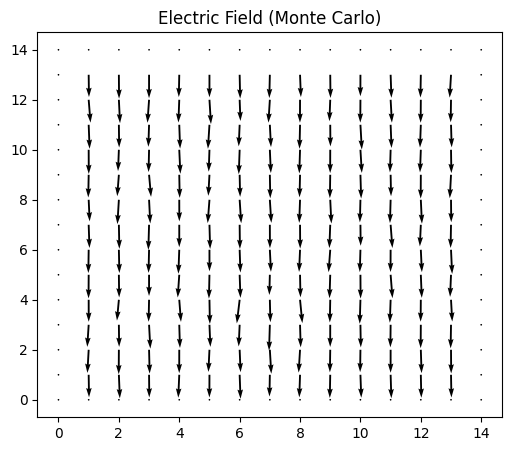

In [22]:
def compute_electric_field(V, Nx, Ny):
    Ex = np.zeros_like(V)
    Ey = np.zeros_like(V)

    for i in range(1, Nx-1):
        for j in range(1, Ny-1):
            Ex[i,j] = -(V[i+1,j] - V[i-1,j]) / 2
            Ey[i,j] = -(V[i,j+1] - V[i,j-1]) / 2

    return Ex, Ey

Ex, Ey = compute_electric_field(V_mc, Nx, Ny)
plt.figure(figsize=(6,5))
plt.quiver(Ex.T, Ey.T)
plt.title("Electric Field (Monte Carlo)")
plt.show()


### Application in European Option Pricing:

The stock price $S_t$ follows a Geometric Brownian Motion, defined by the Stochastic Differential Equation (SDE):

$$dS_t = r S_t dt + \sigma S_t dW_t$$

where $dW_t$ is the increment of a standard Brownian motion ($dW_t \sim N(0, dt)$)

The discrete-time update rule for GBM (derived via Itō's lemma) is:

$$S_t = S_{t-1} \cdot \exp\left( \left(r - \frac{1}{2} \sigma^2\right) dt + \sigma \sqrt{dt} \cdot Z \right)$$

- **$Z$ $ \sim N(0,1)$ (standard normal random variable) and $dt = \frac{T}{\text{steps}}$.
- **$r$ (risk-free interest rate):**  
  This represents the constant rate of return of a riskless asset (e.g., a government bond).  
  Under the risk-neutral measure, it determines the expected growth rate of the asset price.

- **$\sigma$ (volatility):**  
  This measures the uncertainty or randomness in the asset price.  
  A larger $\sigma$ leads to greater fluctuations in the simulated paths.

In [23]:
def random_walk_prices(S0, r, sigma, T, steps, Nwalkers):
  dt = T/steps
  prices = np.zeros((steps+1, Nwalkers))
  prices[0] = S0
  for t in range(1,steps+1):
    Z = np.random.standard_normal(Nwalkers)
    prices[t] = prices[t-1]*np.exp((r-0.5*sigma**2)*dt+sigma*np.sqrt(dt)*Z)
  return prices


The corresponding boundary function is the payoff of a European call option at maturity $T$ is:

$$\text{Payoff}(S_T) = \max(S_T - K, 0)$$

In [24]:
# Financial Model Parameters
S0 = 100.0      # Initial stock price
K = 105.0       # Strike price
r = 0.05        # Risk-free rate
sigma = 0.2     # Volatility (diffusion coefficient)
T = 1.0         # Time to maturity (1 year)
steps = 252     # Number of trading days
Nwalkers_fin = 10000  # Number of simulated paths


#generate the prices
prices = random_walk_prices(S0, r, sigma, T, steps, Nwalkers_fin)

# Extract stock prices at maturity (T)
S_T = prices[-1]

# Implement the payoff formula above
payoffs = np.maximum(S_T - K, 0)

The current option price $V_0$ is the discounted expected payoff under the risk-neutral measure:

$$V_0 = e^{-rT} \cdot \mathbb{E} \left[ \max(S_T - K, 0) \right]$$

In [25]:
option_price = np.exp(-r * T) * np.mean(payoffs)
print("Estimated Option Price:", option_price)

Estimated Option Price: 7.816529772217926


### Visualization:

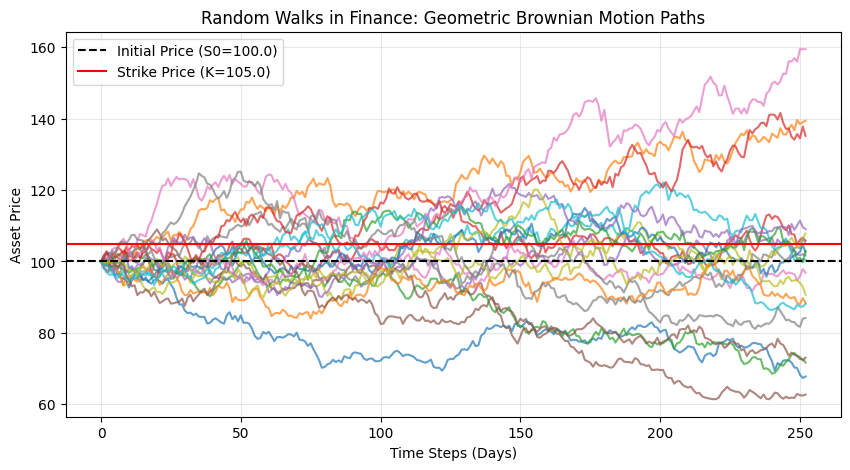

In [26]:
idx = np.random.choice(prices.shape[1], 20, replace=False)
plt.figure(figsize=(10, 5))
plt.plot(prices[:, idx], alpha=0.7)
plt.axhline(y=S0, color='black', linestyle='--', label=f'Initial Price (S0={S0})')
plt.axhline(y=K, color='red', linestyle='-', label=f'Strike Price (K={K})')
plt.title("Random Walks in Finance: Geometric Brownian Motion Paths")
plt.xlabel("Time Steps (Days)")
plt.ylabel("Asset Price")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

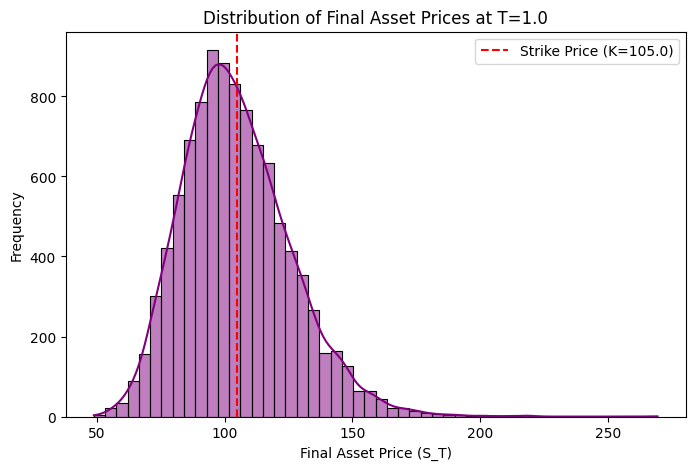

In [27]:
plt.figure(figsize=(8, 5))
sns.histplot(prices[-1], bins=50, kde=True, color='purple')
plt.axvline(x=K, color='red', linestyle='--', label=f'Strike Price (K={K})')
plt.title(f"Distribution of Final Asset Prices at T={T}")
plt.xlabel("Final Asset Price (S_T)")
plt.ylabel("Frequency")
plt.legend()
plt.show()

In [28]:
running_price = (
    np.exp(-r*T)
    * np.cumsum(payoffs)
    / np.arange(1, len(payoffs)+1)
)


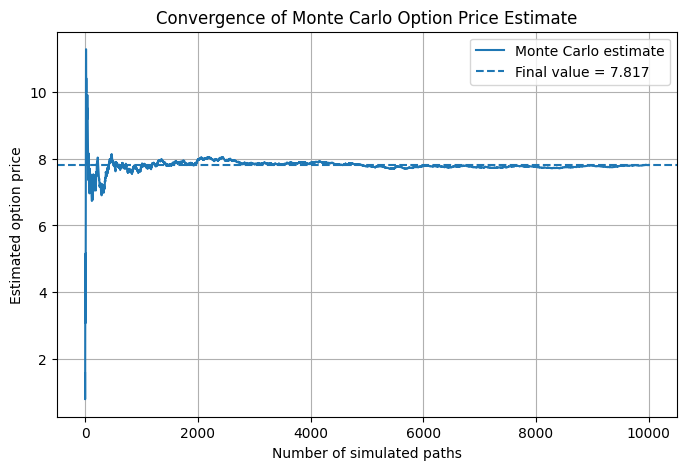

In [29]:
plt.figure(figsize=(8,5))

plt.plot(
    running_price,
    label="Monte Carlo estimate"
)

plt.axhline(
    running_price[-1],
    linestyle="--",
    label=f"Final value = {running_price[-1]:.3f}"
)

plt.xlabel("Number of simulated paths")
plt.ylabel("Estimated option price")
plt.title("Convergence of Monte Carlo Option Price Estimate")

plt.legend()
plt.grid(True)

plt.show()